In [31]:
import warnings
warnings.filterwarnings('ignore')
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:
# US Tech Giants Portfolio
tickers_list = ['AAPL', 'NVDA', 'GOOGL', 'AMZN', 'TSLA']
total_budget = 100000.0
allocation_per_stock = total_budget / len(tickers_list)
transaction_cost_pct = 0.001  # 0.1% transaction friction

portfolio_equity_df = pd.DataFrame()
performance_metrics = []

print(f"=== Running Professional Quant Strategy with Win Rate & Metrics ===\n")

=== Running Professional Quant Strategy with Win Rate & Metrics ===



In [33]:
for symbol in tickers_list:
    frame = yf.download(symbol, start='2024-01-01', end='2026-01-01', progress=False)
    
    if frame.empty:
        continue

    if isinstance(frame.columns, pd.MultiIndex):
        frame.columns = frame.columns.get_level_values(0)

    # Quantitative Strategy Signals: Fast MA and Slow MA Crossover
    frame['MA_Fast'] = frame['Close'].rolling(window=20).mean()
    frame['MA_Slow'] = frame['Close'].rolling(window=50).mean()
    
    # Signal: 1 when Fast MA > Slow MA (Bullish), else 0 (Cash/Flat)
    frame['Signal'] = 0
    frame.loc[frame['MA_Fast'] > frame['MA_Slow'], 'Signal'] = 1
    
    # Shift signal to avoid look-ahead bias
    frame['Position'] = frame['Signal'].shift(1)
    
    # Calculate daily returns
    frame['Market_Return'] = frame['Close'].pct_change()
    
    # Strategy returns with transaction cost on position changes
    frame['Trade'] = frame['Position'].diff().abs().fillna(0)
    frame['Strategy_Return'] = (frame['Market_Return'] * frame['Position']) - (frame['Trade'] * transaction_cost_pct)
    
    # Equity curve calculation for this stock
    equity_curve = allocation_per_stock * (1 + frame['Strategy_Return'].fillna(0)).cumprod()
    portfolio_equity_df[symbol] = equity_curve

    # Win Rate Calculation (Percentage of positive return trading days/periods when in position)
    active_trades = frame[frame['Position'] == 1]['Strategy_Return'].dropna()
    if len(active_trades) > 0:
        winning_trades = active_trades[active_trades > 0]
        win_rate = (len(winning_trades) / len(active_trades)) * 100
    else:
        win_rate = 0.0

    # Risk & Performance Metrics Calculation
    final_val = equity_curve.iloc[-1]
    total_return = (final_val - allocation_per_stock) / allocation_per_stock
    
    # Sharpe Ratio (Assuming risk-free rate = 0)
    strat_rets = frame['Strategy_Return'].dropna()
    sharpe_ratio = np.sqrt(252) * (strat_rets.mean() / strat_rets.std()) if strat_rets.std() != 0 else 0
    
    # Max Drawdown
    rolling_max = equity_curve.cummax()
    drawdown = (equity_curve - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    performance_metrics.append({
        'Stock': symbol,
        'Final Value ($)': round(final_val, 2),
        'Return (%)': round(total_return * 100, 2),
        'Win Rate (%)': round(win_rate, 2),
        'Sharpe Ratio': round(sharpe_ratio, 2),
        'Max Drawdown (%)': round(max_drawdown * 100, 2)
    })

    print(f"Stock: {symbol}")
    print(f" -> Final Value: ${round(final_val, 2)} | Return: {round(total_return * 100, 2)}% | Win Rate: {round(win_rate, 2)}%")
    print(f" -> Sharpe Ratio: {round(sharpe_ratio, 2)} | Max Drawdown: {round(max_drawdown * 100, 2)}%\n")


Stock: AAPL
 -> Final Value: $26698.53 | Return: 33.49% | Win Rate: 57.0%
 -> Sharpe Ratio: 0.89 | Max Drawdown: -25.03%

Stock: NVDA
 -> Final Value: $32550.38 | Return: 62.75% | Win Rate: 52.75%
 -> Sharpe Ratio: 0.92 | Max Drawdown: -23.49%

Stock: GOOGL
 -> Final Value: $42330.04 | Return: 111.65% | Win Rate: 56.89%
 -> Sharpe Ratio: 1.69 | Max Drawdown: -18.14%

Stock: AMZN
 -> Final Value: $19991.67 | Return: -0.04% | Win Rate: 52.78%
 -> Sharpe Ratio: 0.11 | Max Drawdown: -23.49%

Stock: TSLA
 -> Final Value: $45635.07 | Return: 128.18% | Win Rate: 51.06%
 -> Sharpe Ratio: 1.13 | Max Drawdown: -27.84%



In [34]:
# Combine Portfolio
portfolio_equity_df = portfolio_equity_df.dropna()
portfolio_equity_df['Total_Portfolio'] = portfolio_equity_df.sum(axis=1)

# Final Portfolio Summary
final_portfolio_val = portfolio_equity_df['Total_Portfolio'].iloc[-1]
net_pl = final_portfolio_val - total_budget
total_portfolio_return = (net_pl / total_budget) * 100

print("-" * 70)
print(f"Total Initial Portfolio Value: ${total_budget}")
print(f"Total Final Portfolio Value: ${round(final_portfolio_val, 2)}")
print(f"Net P&L: ${round(net_pl, 2)} ({round(total_portfolio_return, 2)}%)")
print("-" * 70)

----------------------------------------------------------------------
Total Initial Portfolio Value: $100000.0
Total Final Portfolio Value: $167205.7
Net P&L: $67205.7 (67.21%)
----------------------------------------------------------------------



Professional Performance Summary Table:
Stock  Final Value ($)  Return (%)  Win Rate (%)  Sharpe Ratio  Max Drawdown (%)
 AAPL         26698.53       33.49         57.00          0.89            -25.03
 NVDA         32550.38       62.75         52.75          0.92            -23.49
GOOGL         42330.04      111.65         56.89          1.69            -18.14
 AMZN         19991.67       -0.04         52.78          0.11            -23.49
 TSLA         45635.07      128.18         51.06          1.13            -27.84


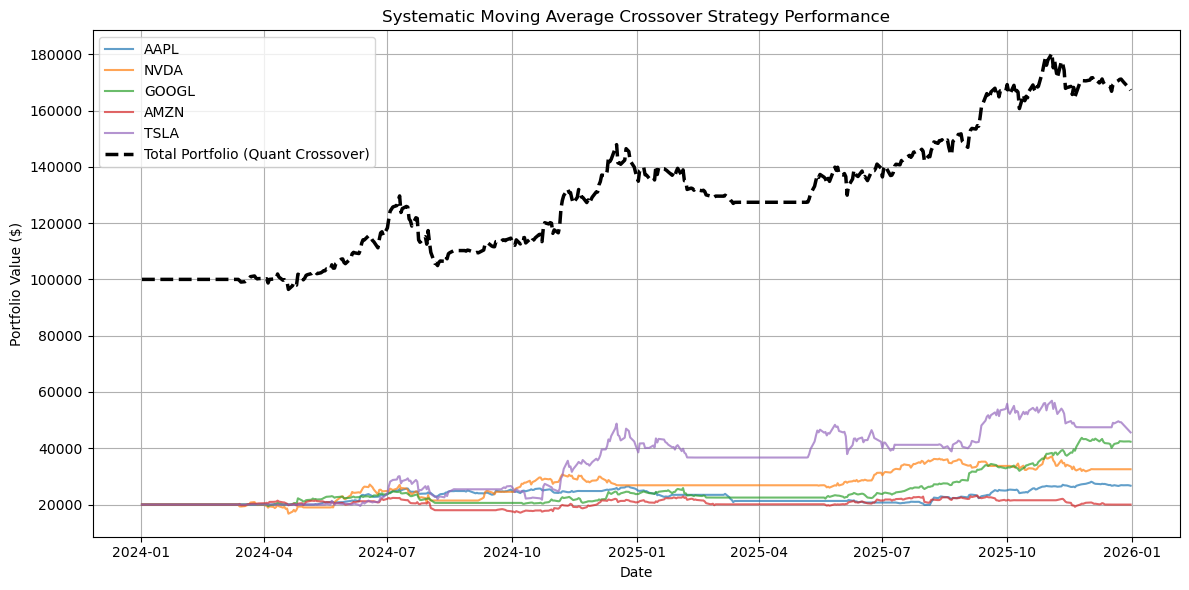

In [36]:
# Print Summary Table with Win Rate
metrics_df = pd.DataFrame(performance_metrics)
print("\nProfessional Performance Summary Table:")
print(metrics_df.to_string(index=False))

# Graph Plotting
plt.figure(figsize=(12, 6))
for symbol in tickers_list:
    if symbol in portfolio_equity_df.columns:
        plt.plot(portfolio_equity_df.index, portfolio_equity_df[symbol], label=symbol, alpha=0.7)

plt.plot(portfolio_equity_df.index, portfolio_equity_df['Total_Portfolio'], label='Total Portfolio (Quant Crossover)', color='black', linewidth=2.5, linestyle='--')

plt.title('Systematic Moving Average Crossover Strategy Performance')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()